# Lab: K-Nearest Neighbors Classifier



## Objectives

After completing this lab you will be able to:

*   Use K-Nearest neighbors to classify data
*   Apply KNN classifier on a real world data set 

Imagine a telecommunications provider has segmented its customer base by service usage patterns, categorizing the customers into four groups. If demographic data can be used to predict group membership, the company can customize offers for individual prospective customers. It is a classification problem. That is, given the dataset,  with predefined labels, we need to build a model to be used to predict class of a new or unknown case.

The example focuses on using demographic data, such as region, age, and marital, to predict usage patterns.

The target field, called **custcat**, has four possible service categories that correspond to the four customer groups, as follows:

1. Basic Service
2. E-Service
3. Plus Service
4. Total Service

Our objective is to build a classifier to predict the service category for unknown cases. We will use a specific type of classification called K-nearest neighbors.


In [12]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests


In [2]:
def download (url, fileName):
    response = requests.get(url)
    if(response.status_code == 200):
        with open(fileName, "wb") as f:
            f.write(response.content)

In [3]:
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv'
file_name =  "teleCust1000t.csv"

In [4]:
download(path, file_name)

In [6]:
df = pd.read_csv(file_name)
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


## Data Preprocessing

In [7]:
# check null values
df.isnull().sum()

region     0
tenure     0
age        0
marital    0
address    0
income     0
ed         0
employ     0
retire     0
gender     0
reside     0
custcat    0
dtype: int64

### Data Visualization and Analysis

Let us first look at the class-wise distribution of the data set.




In [11]:
df['custcat'].value_counts()

custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64

Hence, we can say that we have records of 281 customers who opt for Plus Services, 266 for Basic-services, 236 for Total Services, and 217 for E-Services. It can thus be seen that the data set is mostly balanced between the different classes and requires no special means of accounting for class bias.


We can also visualize the correlation map of the data set to determine how the different features are related to each other. 


<Axes: >

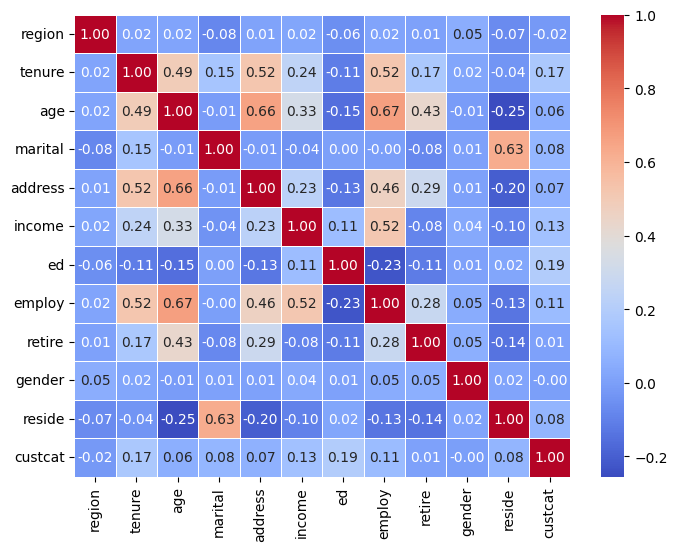

In [15]:
# check the correlation among features
corr_values = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_values, cmap='coolwarm', annot=True,fmt='.2f', linewidths=0.5)

As is visible from the correlation map, some features have beeter correlation among them than others, basically indicating the depth of relationship between the two features. What is of interest to us is the correlation of the target feature, i.e. `custcat` with all the other features. This will help us identify which features should be focussed on for modeling and which ones can be ignored. 

The following code snippet will give us a list of features sorted in the descending order of their absolute correlation values with respect to the target field.


In [16]:
# filter and get the maxium features which have highest correlation
corr_matrix = df.corr()['custcat'].drop('custcat')
corr_matrix = corr_matrix.sort_values(ascending=False)
corr_matrix

ed         0.193864
tenure     0.166691
income     0.134525
employ     0.110011
marital    0.083836
reside     0.082022
address    0.067913
age        0.056909
retire     0.008908
gender    -0.004966
region    -0.023771
Name: custcat, dtype: float64

### Separate the input and target features


In [19]:
x_data = df.drop('custcat',axis =1)
y_data = df['custcat']

print("x data set:\n", x_data.head())
print("\ny data set:\n", y_data.head())


x data set:
    region  tenure  age  marital  address  income  ed  employ  retire  gender  \
0       2      13   44        1        9    64.0   4       5     0.0       0   
1       3      11   33        1        7   136.0   5       5     0.0       0   
2       3      68   52        1       24   116.0   1      29     0.0       1   
3       2      33   33        0       12    33.0   2       0     0.0       1   
4       2      23   30        1        9    30.0   1       2     0.0       0   

   reside  
0       2  
1       6  
2       2  
3       1  
4       4  

y data set:
 0    1
1    4
2    3
3    1
4    3
Name: custcat, dtype: int64
